# 09 — Job Seeker Guide

Synthesis notebook combining insights A1-A8 into 4 actionable job seeker personas. Translates the analytical findings from the previous notebooks into concrete guidance on skills to prioritise, cities to target, and salary expectations for each persona type.

In [7]:
from analysis.utils import notebook_init

df = notebook_init()

Loaded 19,148 rows × 29 columns


In [8]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar
from analysis.filters import filter_by_seniority, filter_remote, salary_df, explode_json_col

df.head(3)

,row_id,job_url,date_posted,company_name,city,state,title,title_cleaned,job_family,job_summary,...,nice_to_have_skills,benefits,tasks,languages,benefit_categories,soft_skill_categories,description_quality,site,validation_flags,description
0,c3b86e465187,https://de.linkedin.com/jobs/view/softwareentw...,2025-11-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,Softwareentwickler / Data Engineer DevOps (mwd),Software Developer / Data Engineer DevOps,Data Engineer,Software Developer / Data Engineer DevOps crea...,...,"[""AWS"", ""Azure"", ""Scripting Languages""]","[""Flexible working hours"", ""Mobile Office / hy...","[""Create, extend and operate innovative, perfo...",[],"[""compensation"", ""education"", ""flexible_hours""...","[""Communication"", ""Customer Focus"", ""Teamwork""]",concatenated,linkedin,[],Unsere über 30-jährige Erfolgsgeschichte im So...
1,a85937eee245,https://de.linkedin.com/jobs/view/werkstudent-...,2025-12-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,"Werkstudent (mwd) Data Analytics, BI & Reporting","Working Student Data Analytics, BI & Reporting",Working Student,"Working student supporting data analytics, BI,...",...,"[""MS PowerBI""]","[""Flexible working hours"", ""Mobile Office/hybr...","[""Building and maintaining modern data pipelin...",[],"[""education"", ""flexible_hours"", ""food"", ""healt...","[""Teamwork""]",concatenated,linkedin,"[{""field"": ""contract_type"", ""rule"": ""intern_co...",Unsere über 35-jährige Erfolgsgeschichte im So...
2,afa0059eab62,https://de.linkedin.com/jobs/view/system-admin...,2026-01-16,NZR Nordwestdeutsche Zählerrevision Ing. Aug. ...,Bad Laer,Lower Saxony,System-Administrator (m/w/d),System-Administrator,System Administrator,System administrator responsible for maintaini...,...,"[""InforCom ERP""]","[""29 vacation days"", ""Flexible working hours"",...","[""Ensuring smooth IT operations across entire ...",[],"[""education"", ""flexible_hours"", ""health"", ""mob...","[""Structured Work"", ""Teamwork""]",concatenated,linkedin,"[{""field"": ""technical_skills"", ""rule"": ""skill_...",Ihre Vorteile bei NZR:Ein attraktives Gehalt i...


## The 4 Personas (Junior, Senior, Remote-First, Career-Changer)

In [9]:
import pandas as pd

personas = {
    "Junior": filter_by_seniority(df, "Junior"),
    "Senior": df[df["seniority_from_title"].isin(["Senior", "Lead"])],
    "Remote-First": filter_remote(df),
    "Career-Changer": df[df["job_family"].str.lower() == "other"],
}

summary_rows = []
for name, pdf in personas.items():
    sdf = salary_df(pdf)
    summary_rows.append({
        "Persona": name,
        "Count": len(pdf),
        "% of market": f"{len(pdf)/len(df)*100:.1f}%",
        "Top job family": pdf["job_family"].value_counts().index[0] if len(pdf) else "N/A",
        "Median salary (EUR)": int(sdf["salary_mid"].median()) if len(sdf) else "N/A",
        "Remote %": f"{(pdf['work_modality'].str.lower() == 'remote').mean()*100:.1f}%",
    })

pd.DataFrame(summary_rows).set_index("Persona")

,Count,% of market,Top job family,Median salary (EUR),Remote %
Persona,,,,,
Junior,751,3.9%,Other,47500,30.2%
Senior,5116,26.7%,SAP Consultant,77500,26.6%
Remote-First,4660,24.3%,Fullstack Developer,70000,100.0%
Career-Changer,630,3.3%,Other,62500,30.5%


## Skills Roadmap by Persona

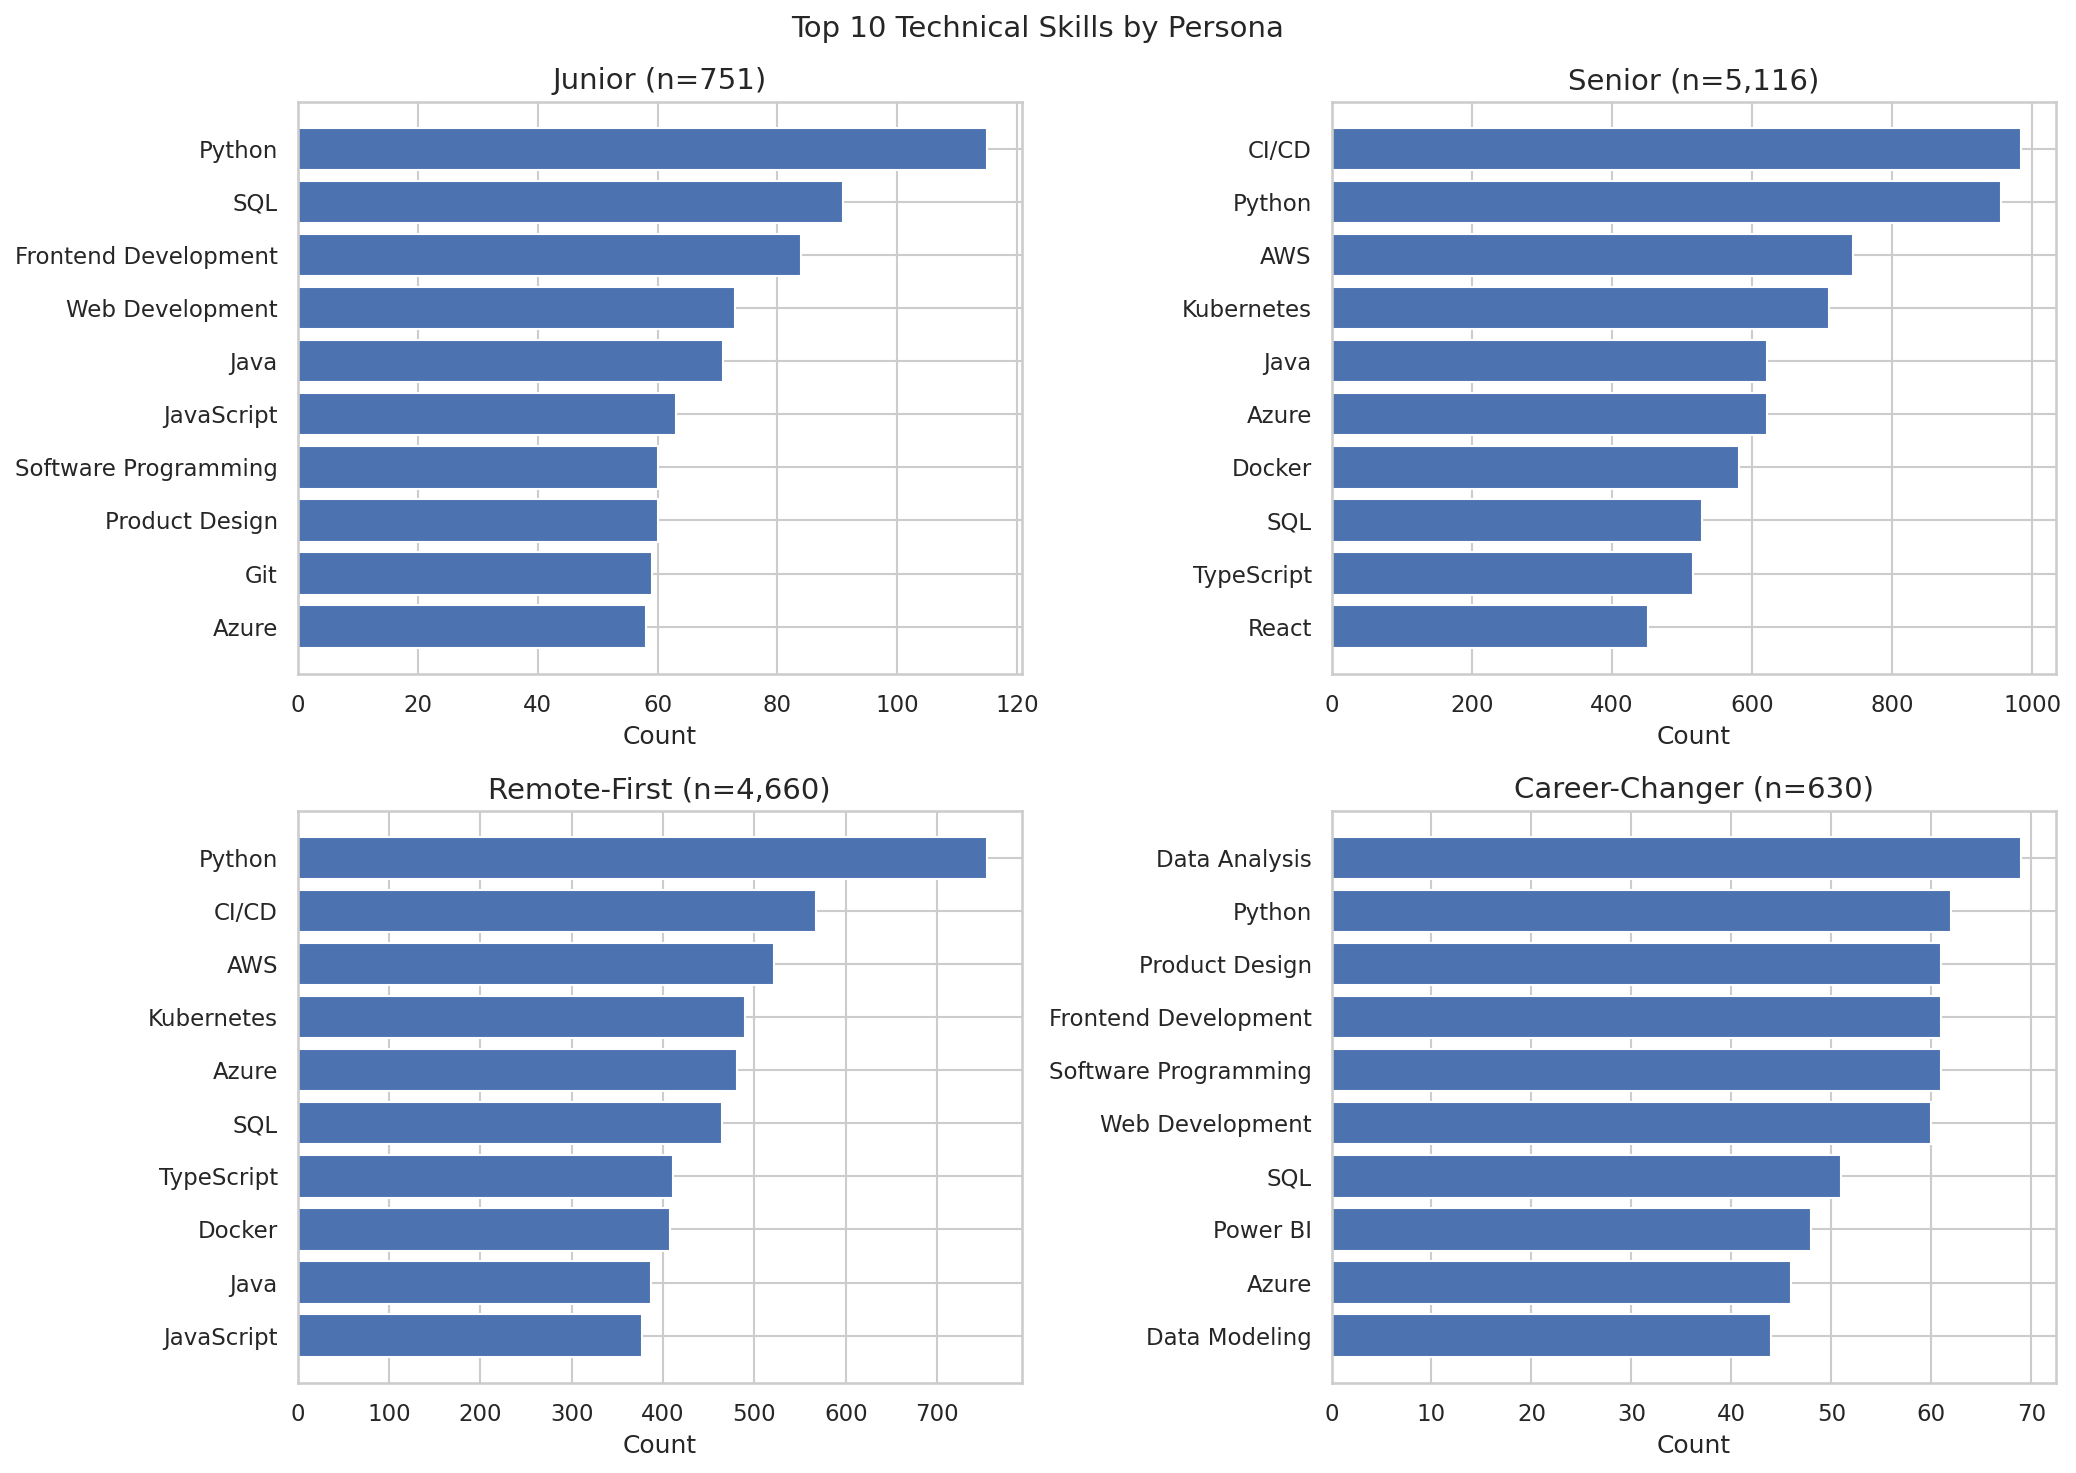

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Top 10 Technical Skills by Persona", fontsize=14)

for ax, (name, pdf) in zip(axes.flat, personas.items()):
    if len(pdf) == 0:
        ax.set_title(name)
        continue
    top_skills = (
        explode_json_col(pdf, "technical_skills")["technical_skills"]
        .value_counts()
        .head(10)
        .sort_values()
    )
    ax.barh(top_skills.index, top_skills.values)
    ax.set_title(f"{name} (n={len(pdf):,})")
    ax.set_xlabel("Count")

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "09_skills_by_persona.png", dpi=150)

## Best Cities per Persona

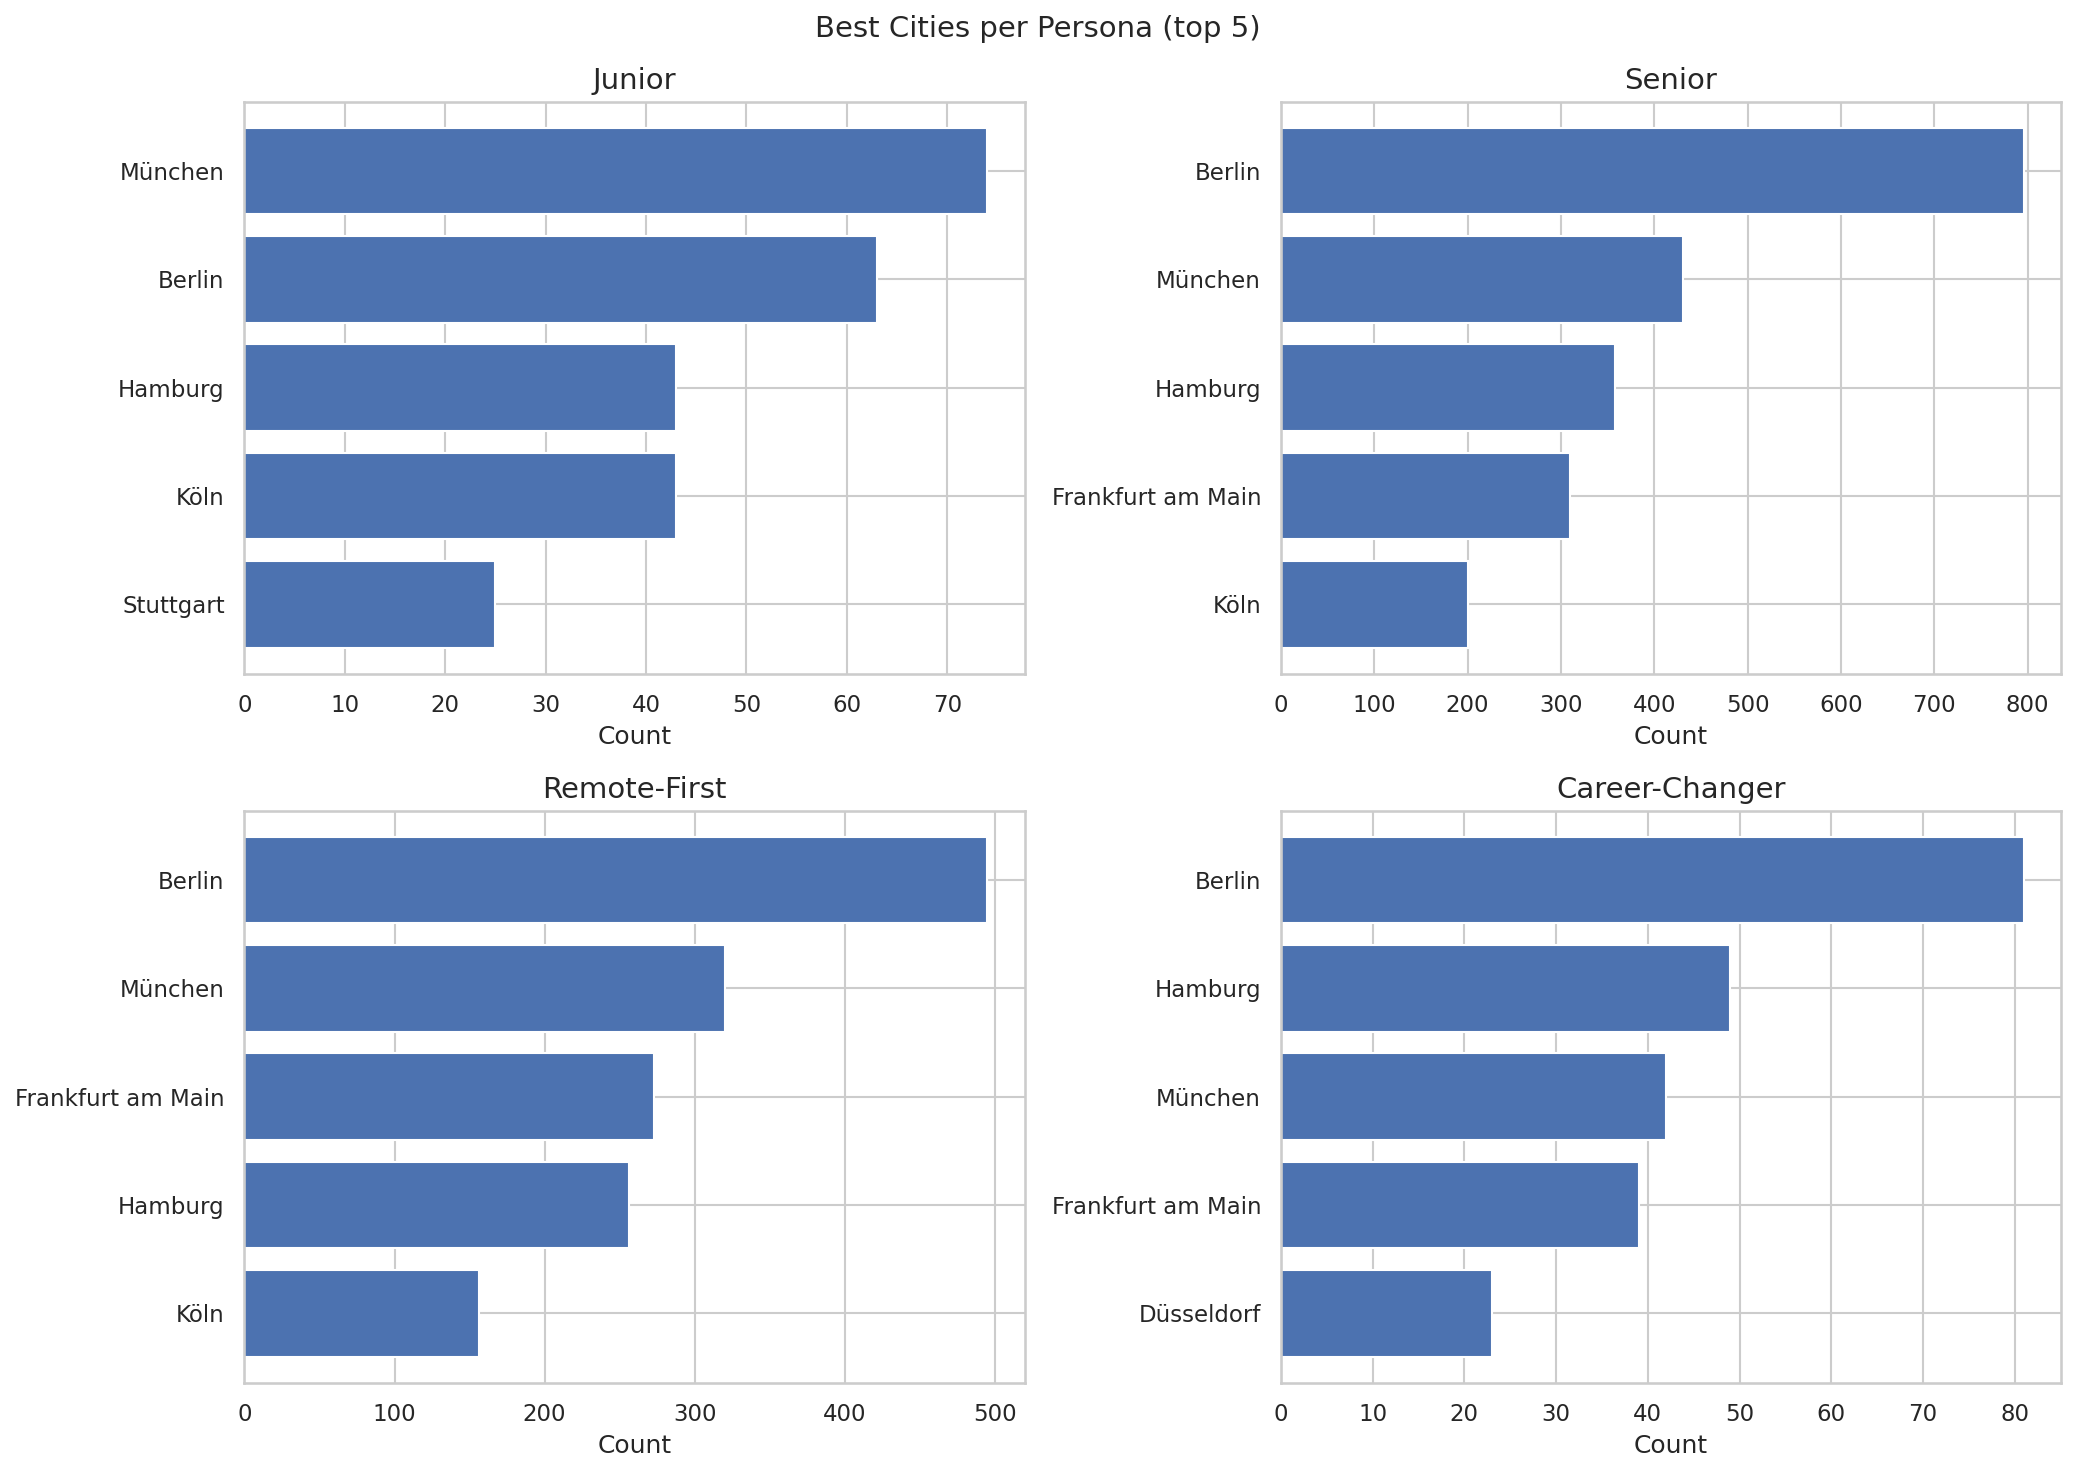

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Best Cities per Persona (top 5)", fontsize=14)

for ax, (name, pdf) in zip(axes.flat, personas.items()):
    city_df = pdf[pdf["city"].notna()]
    if len(city_df) == 0:
        ax.set_title(name)
        continue
    top_cities = city_df["city"].value_counts().head(5).sort_values()
    ax.barh(top_cities.index, top_cities.values)
    ax.set_title(f"{name}")
    ax.set_xlabel("Count")

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "09_cities_by_persona.png", dpi=150)

## Salary Expectations

In [12]:
salary_rows = []
for name, pdf in personas.items():
    sdf = salary_df(pdf)
    if len(sdf) == 0:
        salary_rows.append({"Persona": name, "Count (salary known)": 0, "Median": "N/A", "P25": "N/A", "P75": "N/A"})
        continue
    salary_rows.append({
        "Persona": name,
        "Count (salary known)": len(sdf),
        "Median": f"€{int(sdf['salary_mid'].median()):,}",
        "P25": f"€{int(sdf['salary_mid'].quantile(0.25)):,}",
        "P75": f"€{int(sdf['salary_mid'].quantile(0.75)):,}",
    })

pd.DataFrame(salary_rows).set_index("Persona")

,Count (salary known),Median,P25,P75
Persona,,,,
Junior,10,"€47,500","€42,375","€56,875"
Senior,120,"€77,500","€67,500","€95,625"
Remote-First,149,"€70,000","€57,500","€90,000"
Career-Changer,7,"€62,500","€52,650","€112,500"


## Top Cities by Job Family

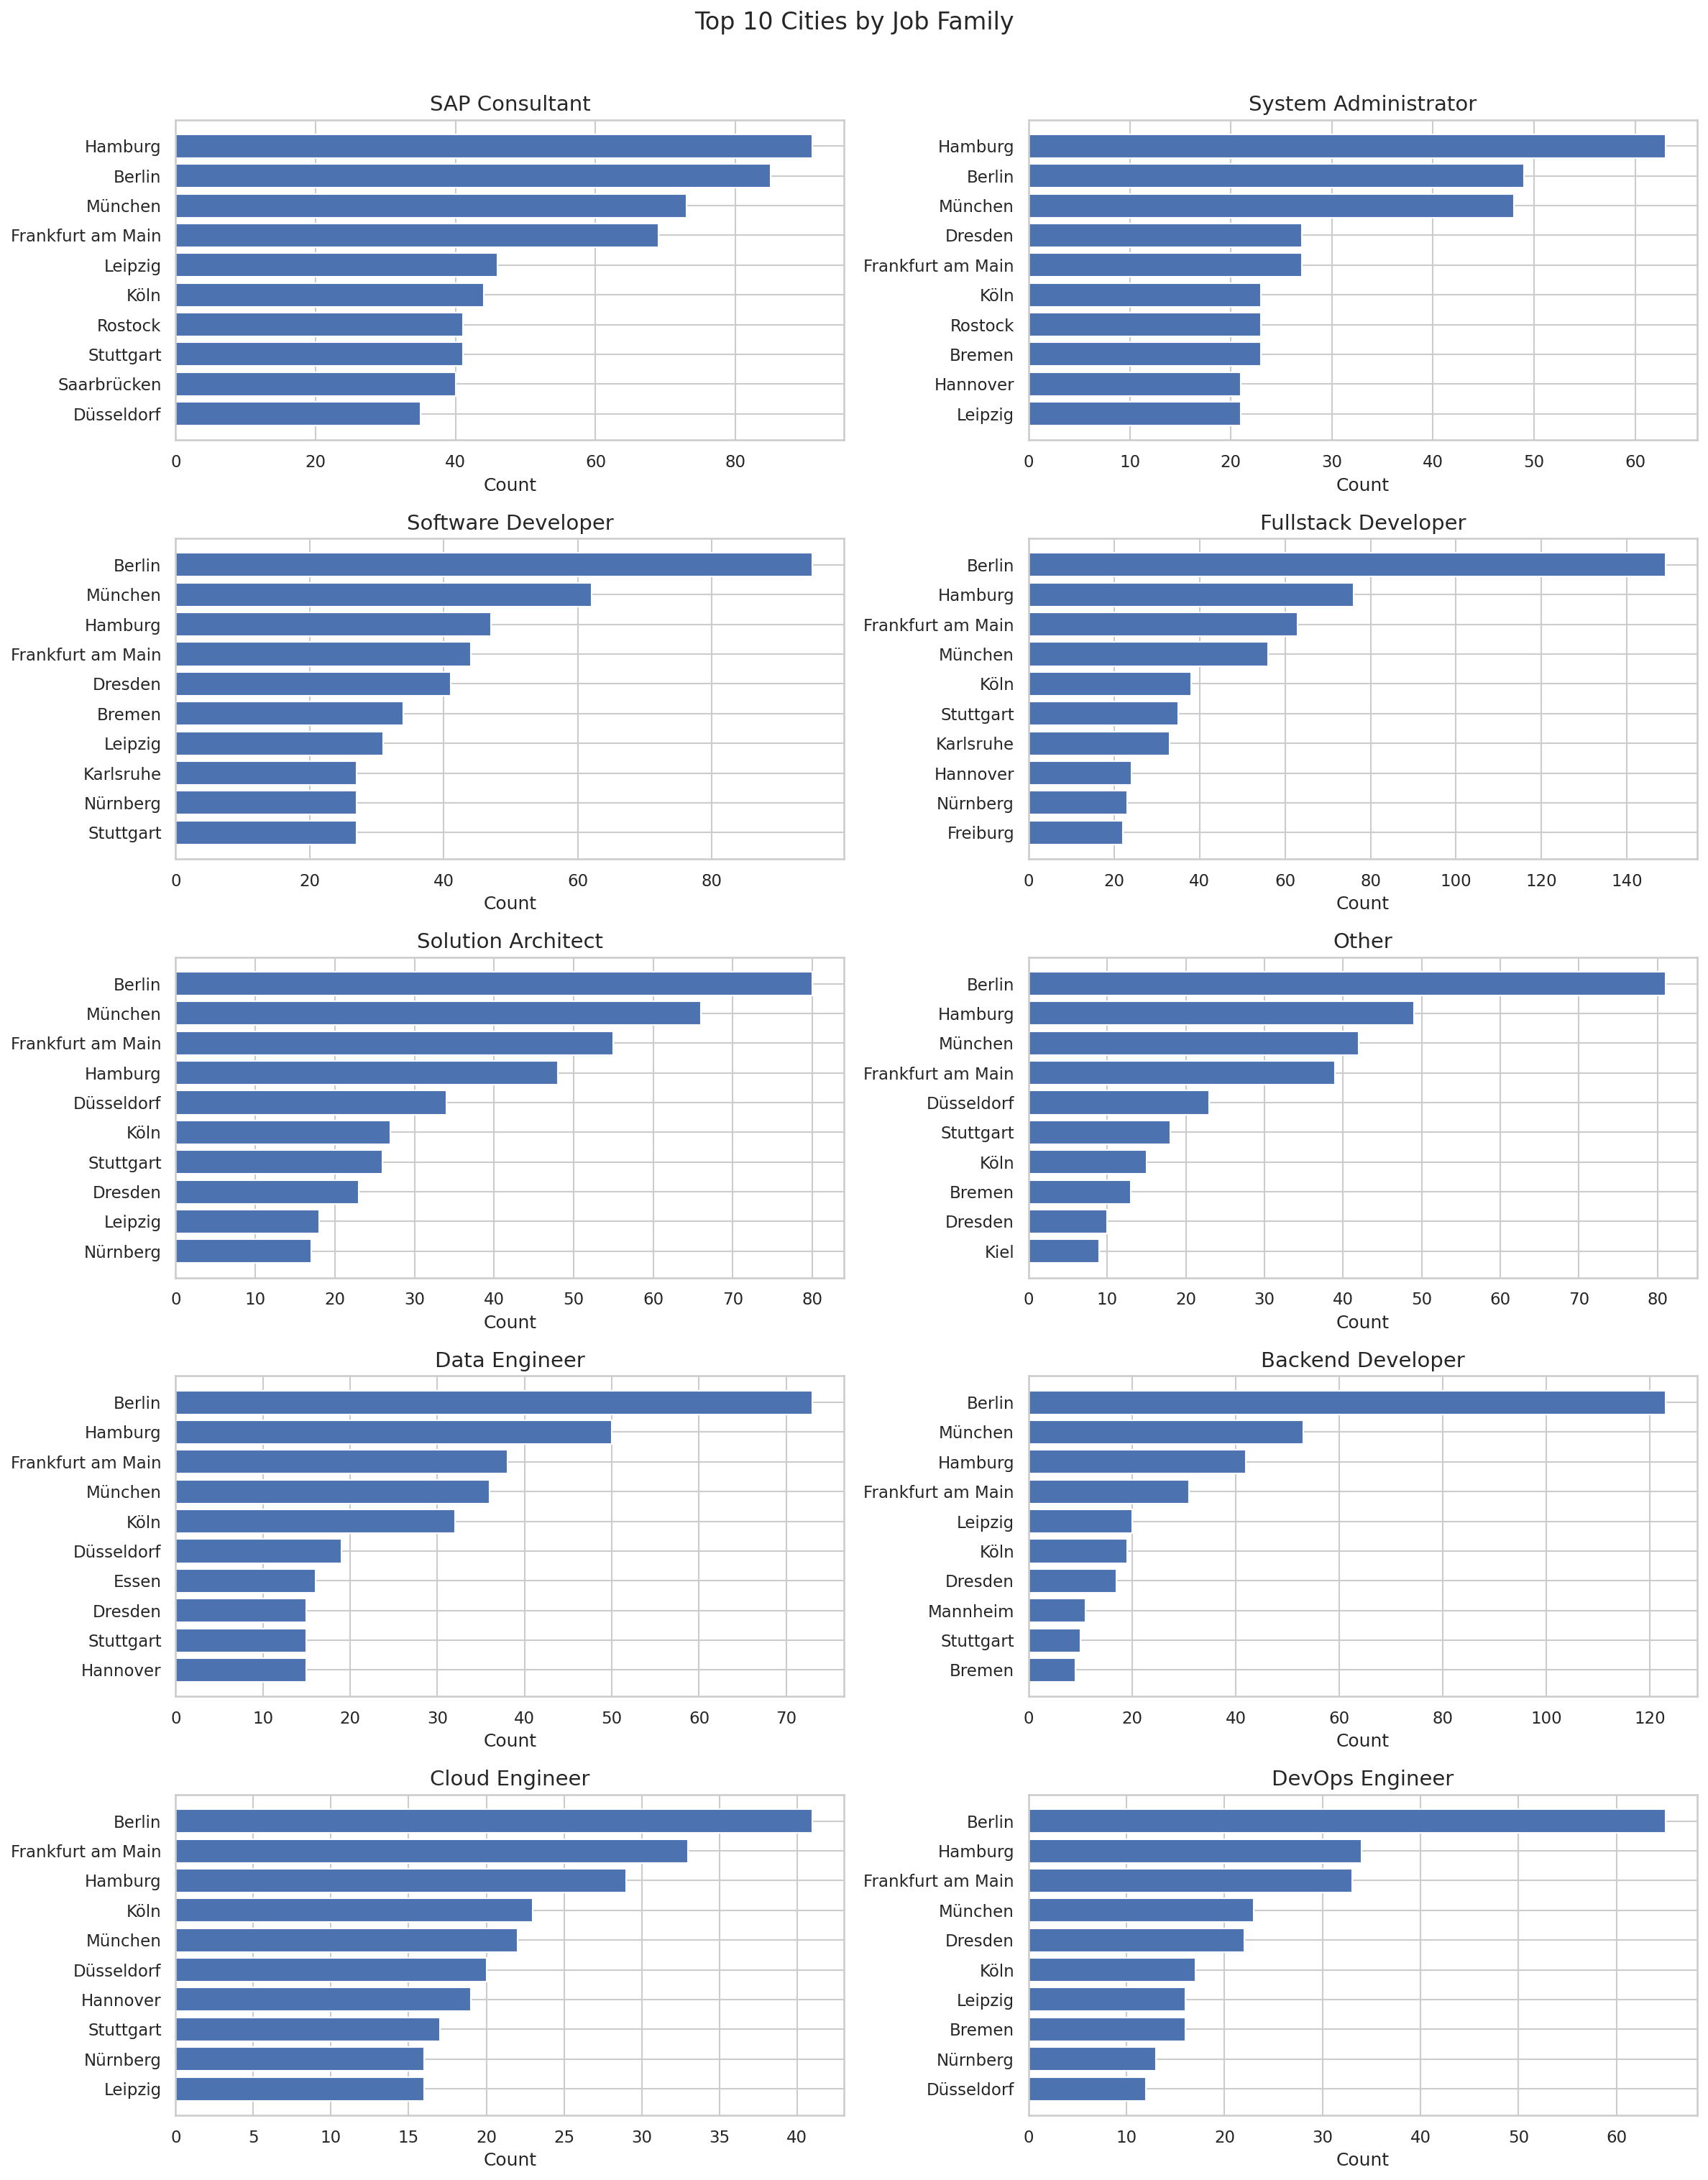

In [13]:
import numpy as np

top_families = df["job_family"].value_counts().head(10).index
city_df = df[df["city"].notna()]

rows = int(np.ceil(len(top_families) / 2))
fig, axes = plt.subplots(rows, 2, figsize=(16, 4 * rows))
fig.suptitle("Top 10 Cities by Job Family", fontsize=16, y=1.01)

for ax, family in zip(axes.flat, top_families):
    family_cities = city_df[city_df["job_family"] == family]["city"].value_counts().head(10).sort_values()
    ax.barh(family_cities.index, family_cities.values)
    ax.set_title(family)
    ax.set_xlabel("Count")

# Hide unused axes
for ax in axes.flat[len(top_families):]:
    ax.set_visible(False)

plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "09_cities_by_family.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## Median Salary by Job Family

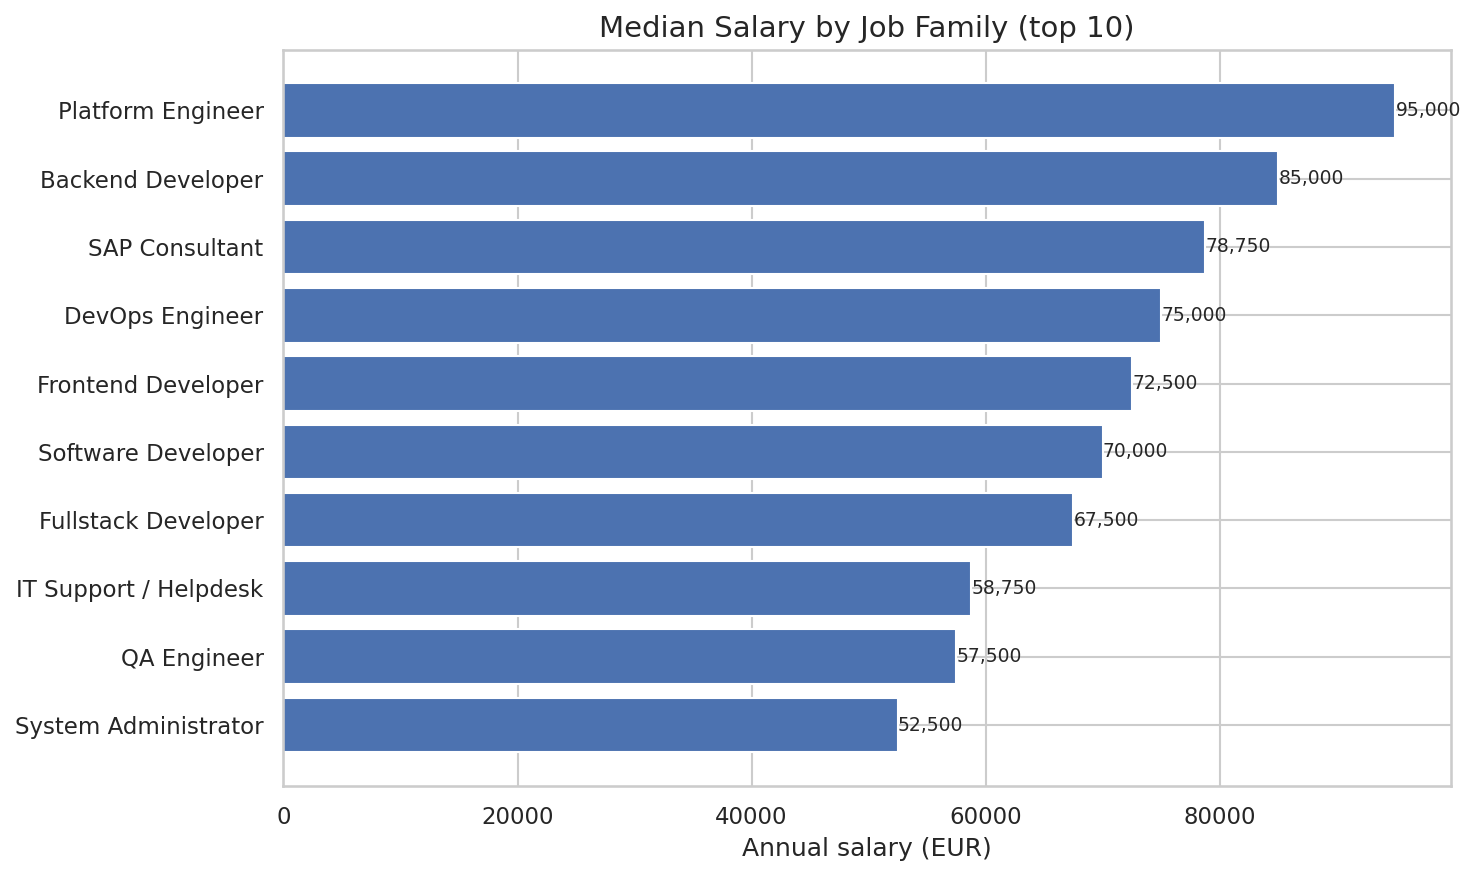

In [14]:
from analysis.charts import value_bar

sdf_all = salary_df(df)
top_families_salary = sdf_all["job_family"].value_counts().head(10).index

family_median = (
    sdf_all[sdf_all["job_family"].isin(top_families_salary)]
    .groupby("job_family")["salary_mid"]
    .median()
    .sort_values()
)

value_bar(
    family_median.index,
    family_median.values,
    "Median Salary by Job Family (top 10)",
    xlabel="Annual salary (EUR)",
    fmt=",.0f",
    save_as="09_salary_by_family.png",
)